# Termination and Square-Wave Reflectometry: Cable Speed Estimation

## Experiment setup

Reflectometry bench setup used for this run:

```text
Square-wave signal generator (2.5 MHz @ 0 dBm)
-[SMA to BNC]-> T-junction
  |- [BNC to BNC]-> same long cable of unknown length (far end open / floating)
  |- [BNC to SMA]-> 3 dB attenuator -[SMA to BNC]-> oscilloscope
```

Measurement principle: the source-side waveform is the superposition of injected and reflected signals. The measured delay corresponds to round-trip travel time in the long cable.

## Procedure used for this notebook

1. Use one measured superposed waveform trace.
2. Mark timing boundaries (ns) of transitions/plateaus from the trace.
3. Build an annotated waveform plot with those timing marks.
4. Define modulo delay as

$$
\Delta t_{\mathrm{mod}} = t_{\mathrm{start,max\ plateau}} - t_{\mathrm{start,first\ plateau}}.
$$

5. Resolve square-wave period ambiguity with period $T=1/f$ and candidate delays

$$
\Delta t_n = \Delta t_{\mathrm{mod}} + nT,\quad n=0,1,2,3.
$$

6. Compute propagation speed via

$$
v_{\mathrm{coax}} = \frac{2L}{\Delta t_n},
$$

for both power-loss priors:

- SDR linear prior: $L=40.0589\,\mathrm{m}$
- Meter linear prior: $L=35.9035\,\mathrm{m}$

### Length convention (locked)

This reflectometry run is through the **unknown cable only**. The 12 ft lead-in from the calibration workflow is **not included** here.

### Required metadata to log for full reproducibility

- Oscilloscope settings: input impedance, coupling mode, bandwidth limit, probe factor.
- Scope acquisition settings: sample rate, timebase, trigger mode/source/level.
- Component IDs: tee part, attenuator part/value, cable IDs and adapter chain.
- Raw trace provenance: saved waveform file path and timestamp.
- Timing-pick uncertainty: per-edge pick uncertainty and propagation rule to $\Delta t$ and $v_{\mathrm{coax}}$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Constants and timing picks
F_HZ = 2.5e6
T_NS = 1e9 / F_HZ  # 400 ns
C_MPS = 299_792_458.0
VF_TARGET = 0.66

# User-picked boundary times [ns]
TIMES_NS = np.array([-428, -402, -324, -304, -230, -202, -124, -104, -26], dtype=float)

# Delay definition requested by user:
# start of first plateau -> start of second (maximum) plateau
T_FIRST_PLATEAU_START_NS = -402.0
T_MAX_PLATEAU_START_NS = -304.0
TAU_MOD_NS = T_MAX_PLATEAU_START_NS - T_FIRST_PLATEAU_START_NS

# Length priors [m] (lead-in omitted)
L_SDR_M = 40.0589
L_METER_M = 35.9035

print(f"f = {F_HZ/1e6:.3f} MHz, T = {T_NS:.1f} ns")
print(f"tau_mod = {TAU_MOD_NS:.1f} ns")
print(f"L_sdr = {L_SDR_M:.4f} m, L_meter = {L_METER_M:.4f} m")

f = 2.500 MHz, T = 400.0 ns
tau_mod = 98.0 ns
L_sdr = 40.0589 m, L_meter = 35.9035 m


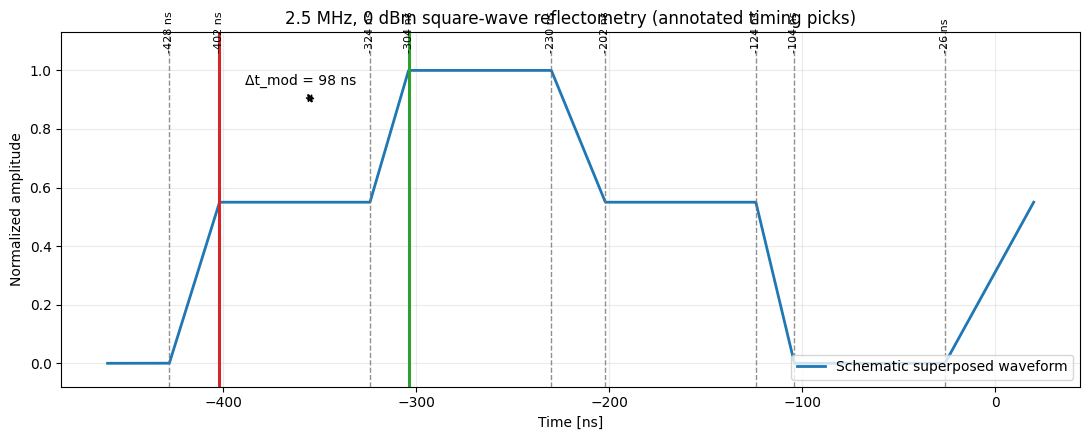

In [2]:
# Build a schematic waveform from timing picks (normalized amplitude)
# Regions are chosen to reflect the described trace shape.

t_grid = np.linspace(-460, 20, 2400)

# Anchor points for piecewise-linear construction
# baseline -> rise -> first plateau -> rise -> max plateau -> fall -> last plateau -> fall -> min plateau -> next rise
anchor_t = np.array([-460, -428, -402, -324, -304, -230, -202, -124, -104, -26, 20], dtype=float)
anchor_y = np.array([0.00, 0.00, 0.55, 0.55, 1.00, 1.00, 0.55, 0.55, 0.00, 0.00, 0.55], dtype=float)

wave = np.interp(t_grid, anchor_t, anchor_y)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_grid, wave, lw=2.0, color='C0', label='Schematic superposed waveform')

# Mark all picked boundaries
for t in TIMES_NS:
    ax.axvline(t, color='0.45', lw=1.0, ls='--', alpha=0.8)
    ax.text(t, 1.06, f"{int(t)} ns", rotation=90, va='bottom', ha='center', fontsize=8)

# Highlight delay definition
ax.axvline(T_FIRST_PLATEAU_START_NS, color='C3', lw=2.2)
ax.axvline(T_MAX_PLATEAU_START_NS, color='C2', lw=2.2)
ax.annotate(
    f"Δt_mod = {TAU_MOD_NS:.0f} ns",
    xy=((T_FIRST_PLATEAU_START_NS + T_MAX_PLATEAU_START_NS) / 2, 0.88),
    xytext=(-360, 0.95),
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.2),
    ha='center',
    fontsize=10,
)

ax.set_title('2.5 MHz, 0 dBm square-wave reflectometry (annotated timing picks)')
ax.set_xlabel('Time [ns]')
ax.set_ylabel('Normalized amplitude')
ax.set_ylim(-0.08, 1.13)
ax.grid(alpha=0.25)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [3]:
# Periodic branches and speed calculation
rows = []
for n in range(4):
    dt_ns = TAU_MOD_NS + n * T_NS
    dt_s = dt_ns * 1e-9
    v_sdr = 2 * L_SDR_M / dt_s
    v_meter = 2 * L_METER_M / dt_s
    rows.append({
        'n': n,
        'delta_t_ns': dt_ns,
        'v_sdr_mps': v_sdr,
        'v_sdr_over_c': v_sdr / C_MPS,
        'v_meter_mps': v_meter,
        'v_meter_over_c': v_meter / C_MPS,
    })

branches = pd.DataFrame(rows)
display(branches)

# Required sanity checks
assert np.isclose(TAU_MOD_NS, 98.0)
assert np.allclose(branches['delta_t_ns'].values, np.array([98.0, 498.0, 898.0, 1298.0]))
assert branches.loc[branches['n'] == 0, 'v_sdr_over_c'].iloc[0] > 1.0
assert branches.loc[branches['n'] == 0, 'v_meter_over_c'].iloc[0] > 1.0

,n,delta_t_ns,v_sdr_mps,v_sdr_over_c,v_meter_mps,v_meter_over_c
0,0,98.0,8.175286e+08,2.726982,7.327245e+08,2.444106
1,1,498.0,1.608791e+08,0.536635,1.441908e+08,0.480969
2,2,898.0,8.921804e+07,0.297599,7.996325e+07,0.266729
3,3,1298.0,6.172404e+07,0.205889,5.532126e+07,0.184532


In [4]:
# Branch selection rule:
# among subluminal branches, choose n that makes v/c closest to nominal coax VF target (0.66).

def pick_branch(v_over_c_col: str) -> int:
    sub = branches[branches[v_over_c_col] < 1.0].copy()
    sub['vf_dist'] = (sub[v_over_c_col] - VF_TARGET).abs()
    return int(sub.sort_values('vf_dist').iloc[0]['n'])

n_sdr = pick_branch('v_sdr_over_c')
n_meter = pick_branch('v_meter_over_c')

assert n_sdr == 1
assert n_meter == 1

sel = branches[branches['n'] == 1].iloc[0]

print(f"Selected branch (SDR prior): n = {n_sdr}, delta_t = {sel['delta_t_ns']:.1f} ns")
print(f"Selected branch (Meter prior): n = {n_meter}, delta_t = {sel['delta_t_ns']:.1f} ns")
print()
print(f"v_coax (SDR prior)   = {sel['v_sdr_mps']:.3e} m/s = {sel['v_sdr_over_c']:.4f} c")
print(f"v_coax (Meter prior) = {sel['v_meter_mps']:.3e} m/s = {sel['v_meter_over_c']:.4f} c")

Selected branch (SDR prior): n = 1, delta_t = 498.0 ns
Selected branch (Meter prior): n = 1, delta_t = 498.0 ns

v_coax (SDR prior)   = 1.609e+08 m/s = 0.5366 c
v_coax (Meter prior) = 1.442e+08 m/s = 0.4810 c


In [5]:
# Report-ready summary
sel = branches[branches['n'] == 1].iloc[0]

report_lines = [
    '### Final Reflectometry Results (Branch-resolved)',
    '',
    r'Using $\Delta t_{\mathrm{mod}}=98\,\mathrm{ns}$, square-wave period $T=400\,\mathrm{ns}$, and branch $n=1$:',
    '',
    r'$$\Delta t = \Delta t_{\mathrm{mod}} + nT = 98 + 1\times 400 = 498\,\mathrm{ns}. $$',
    '',
    'With lead-in omitted (unknown cable only):',
    '',
    r'- SDR length prior: $L=40.0589\,\mathrm{m}$',
    rf'  $$ v_{{\mathrm{{coax}}}} = \frac{{2L}}{{\Delta t}} = {sel["v_sdr_mps"]:.6e}\,\mathrm{{m/s}} = {sel["v_sdr_over_c"]:.4f}c. $$',
    '',
    r'- Meter length prior: $L=35.9035\,\mathrm{m}$',
    rf'  $$ v_{{\mathrm{{coax}}}} = \frac{{2L}}{{\Delta t}} = {sel["v_meter_mps"]:.6e}\,\mathrm{{m/s}} = {sel["v_meter_over_c"]:.4f}c. $$',
    '',
    'Both priors are reported because both were requested for ambiguity-resolution cross-check.',
]

display(Markdown('\n'.join(report_lines)))

### Final Reflectometry Results (Branch-resolved)

Using $\Delta t_{\mathrm{mod}}=98\,\mathrm{ns}$, square-wave period $T=400\,\mathrm{ns}$, and branch $n=1$:

$$\Delta t = \Delta t_{\mathrm{mod}} + nT = 98 + 1\times 400 = 498\,\mathrm{ns}. $$

With lead-in omitted (unknown cable only):

- SDR length prior: $L=40.0589\,\mathrm{m}$
  $$ v_{\mathrm{coax}} = \frac{2L}{\Delta t} = 1.608791e+08\,\mathrm{m/s} = 0.5366c. $$

- Meter length prior: $L=35.9035\,\mathrm{m}$
  $$ v_{\mathrm{coax}} = \frac{2L}{\Delta t} = 1.441908e+08\,\mathrm{m/s} = 0.4810c. $$

Both priors are reported because both were requested for ambiguity-resolution cross-check.

## Cross-reference: reflectometry in the full calibration chain

Reflectometry here constrains propagation speed and cable-length ambiguity, which feed
the analog calibration model used elsewhere:

\[
L_{\mathrm{roof}} = \frac{v_{\mathrm{coax}}\,\Delta t}{2},\qquad
\mathrm{loss}_{\mathrm{roof}}(\nu) = \alpha(\nu)\,L_{\mathrm{roof}}.
\]

This connects directly to `equipment_calibration.ipynb` (attenuation slope and power-meter
voltage cross-check) and to report-side chain-gain bookkeeping.

In [6]:
# Bridge quantities from this notebook to analog calibration bookkeeping.
if 'branches' in globals() and not branches.empty:
    sel = branches[branches['n'] == 1].iloc[0]
    dt_ns = float(sel['delta_t_ns'])
    print(f'Selected branch delay (n=1): delta_t = {dt_ns:.1f} ns')
    print(f'v_coax/c (SDR prior)        : {float(sel["v_sdr_over_c"]):.6f}')
    print(f'v_coax/c (Meter prior)      : {float(sel["v_meter_over_c"]):.6f}')
else:
    print('Branch table not found; run upstream reflectometry cells first.')

print()
print('Downstream coupling formulas:')
print('  L_roof = v_coax * delta_t / 2')
print('  roof_loss_db = alpha_db_per_m * L_roof')
print('  V_rms = sqrt(50 * P_W),  V_pp = 2*sqrt(2)*V_rms')

Selected branch delay (n=1): delta_t = 498.0 ns
v_coax/c (SDR prior)        : 0.536635
v_coax/c (Meter prior)      : 0.480969

Downstream coupling formulas:
  L_roof = v_coax * delta_t / 2
  roof_loss_db = alpha_db_per_m * L_roof
  V_rms = sqrt(50 * P_W),  V_pp = 2*sqrt(2)*V_rms


## Notes\n\n- This notebook currently uses manual timing picks from one measured waveform trace.\n- If/when raw scope waveforms are added under `data/lab02`, replace the schematic-only step with direct trace loading and automated edge extraction while preserving the same delay definition and ambiguity-resolution policy.\n